# Chapter 6, Example 2: Bethe free energy and loopy belief propagation

This notebook compares three situations:

- a chain, where belief propagation is exact;
- a triangle, where the Bethe approximation ignores one global loop;
- a strongly coupled triangle, where update scheduling and damping affect convergence.

For a pairwise binary model, the Bethe entropy can be written as

$$
H_{\mathrm B}
=\sum_i H(b_i)-\sum_{(i,j)}I_{ij}(b_{ij}),
$$

where

$$
I_{ij}(b_{ij})
=\sum_{x_i,x_j}b_{ij}(x_i,x_j)
\log\frac{b_{ij}(x_i,x_j)}{b_i(x_i)b_j(x_j)}
$$

is the mutual information carried by one edge.  On a tree this counting is exact.  On a loopy graph it becomes an approximation.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch06":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch06").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch06"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

NODE_COLOR = "#30343b"
NODE_TEXT_COLOR = "white"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def binary_entropy_from_magnetization(m):
    m = np.asarray(m, dtype=float)
    q = np.clip((1.0 + m) / 2.0, 1e-15, 1.0 - 1e-15)
    return -(q * np.log(q) + (1.0 - q) * np.log(1.0 - q))

In [2]:
SPINS = np.array([-1, 1])


def exact_pairwise(n, edges, couplings, fields, beta):
    states = np.array(list(product([-1, 1], repeat=n)), dtype=int)
    log_weights = np.array([
        beta * (sum(couplings[e] * s[e[0]] * s[e[1]] for e in edges) + np.dot(fields, s))
        for s in states
    ])
    shift = log_weights.max()
    weights = np.exp(log_weights - shift)
    p = weights / weights.sum()
    log_z = shift + np.log(weights.sum())
    return states, p, log_z


def loopy_bp(n, edges, couplings, fields, beta, damping=0.0, max_iterations=1000, tolerance=1e-11):
    neighbors = {i: [] for i in range(n)}
    for i, j in edges:
        neighbors[i].append(j)
        neighbors[j].append(i)
    messages = {(i, j): np.ones(2) / 2 for i in range(n) for j in neighbors[i]}
    residuals = []
    for _ in range(max_iterations):
        new_messages = {}
        max_change = 0.0
        for i in range(n):
            for j in neighbors[i]:
                raw = np.zeros(2)
                for b, xj in enumerate(SPINS):
                    for a, xi in enumerate(SPINS):
                        incoming = np.exp(beta * fields[i] * xi)
                        for k in neighbors[i]:
                            if k != j:
                                incoming *= messages[(k, i)][a]
                        edge = (i, j) if (i, j) in couplings else (j, i)
                        raw[b] += np.exp(beta * couplings[edge] * xi * xj) * incoming
                raw /= raw.sum()
                updated = damping * messages[(i, j)] + (1.0 - damping) * raw
                updated /= updated.sum()
                new_messages[(i, j)] = updated
                max_change = max(max_change, np.max(np.abs(updated - messages[(i, j)])))
        messages = new_messages
        residuals.append(max_change)
        if max_change < tolerance:
            break

    node_beliefs = []
    for i in range(n):
        b = np.exp(beta * fields[i] * SPINS).astype(float)
        for k in neighbors[i]:
            b *= messages[(k, i)]
        b /= b.sum()
        node_beliefs.append(b)

    edge_beliefs = {}
    for i, j in edges:
        b = np.zeros((2, 2))
        for a, xi in enumerate(SPINS):
            for c, xj in enumerate(SPINS):
                value = np.exp(beta * (couplings[(i, j)] * xi * xj + fields[i] * xi + fields[j] * xj))
                for k in neighbors[i]:
                    if k != j:
                        value *= messages[(k, i)][a]
                for k in neighbors[j]:
                    if k != i:
                        value *= messages[(k, j)][c]
                b[a, c] = value
        b /= b.sum()
        edge_beliefs[(i, j)] = b
    return node_beliefs, edge_beliefs, np.asarray(residuals)


def bethe_log_z(n, edges, couplings, fields, beta, node_beliefs, edge_beliefs):
    energy_term = 0.0
    for i in range(n):
        energy_term += beta * fields[i] * np.dot(node_beliefs[i], SPINS)
    for i, j in edges:
        expectation = sum(edge_beliefs[(i, j)][a, b] * SPINS[a] * SPINS[b]
                          for a in range(2) for b in range(2))
        energy_term += beta * couplings[(i, j)] * expectation
    degrees = {i: 0 for i in range(n)}
    for i, j in edges:
        degrees[i] += 1
        degrees[j] += 1
    h_bethe = sum(entropy(edge_beliefs[e]) for e in edges) \
        - sum((degrees[i] - 1) * entropy(node_beliefs[i]) for i in range(n))
    return energy_term + h_bethe, h_bethe

## Exactness on a chain and approximation on a triangle

Saved: figs/ch06_02_chain_and_triangle.pdf


Saved: figs/ch06_02_chain_and_triangle.png


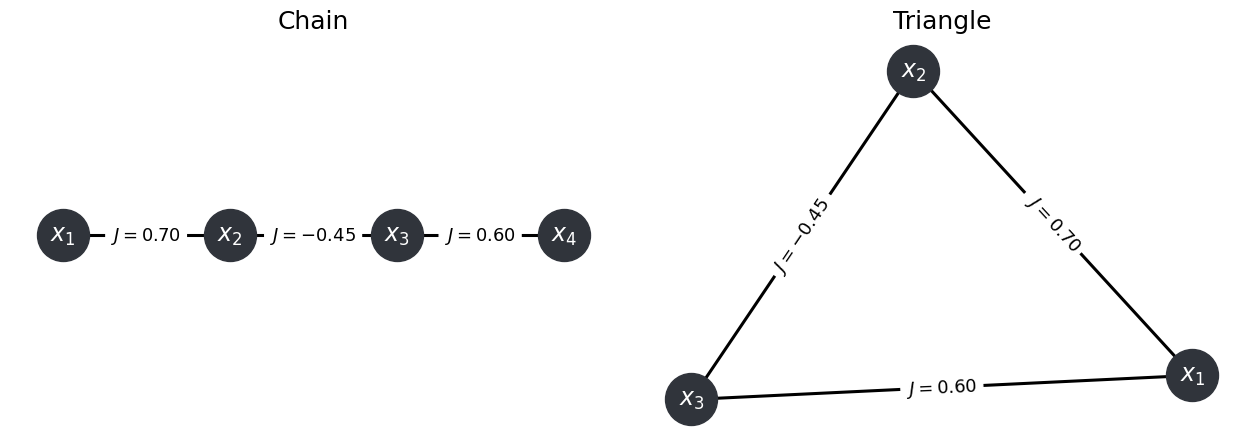

In [3]:
models = {
    "chain": {
        "n": 4,
        "edges": [(0, 1), (1, 2), (2, 3)],
        "couplings": {(0, 1): 0.7, (1, 2): -0.45, (2, 3): 0.6},
        "fields": np.array([0.15, -0.05, 0.10, 0.02]),
    },
    "triangle": {
        "n": 3,
        "edges": [(0, 1), (1, 2), (0, 2)],
        "couplings": {(0, 1): 0.7, (1, 2): -0.45, (0, 2): 0.6},
        "fields": np.array([0.15, -0.05, 0.10]),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.7))
for ax, (name, model) in zip(axes, models.items()):
    graph = nx.Graph(model["edges"])
    position = nx.spring_layout(graph, seed=4) if name == "triangle" else {i: (i, 0) for i in range(model["n"])}
    nx.draw_networkx_nodes(graph, position, node_size=1400, node_color=NODE_COLOR, ax=ax)
    nx.draw_networkx_labels(graph, position, labels={i: rf"$x_{i+1}$" for i in graph.nodes},
                            font_size=17, font_color=NODE_TEXT_COLOR, ax=ax)
    nx.draw_networkx_edges(graph, position, width=2.2, ax=ax)
    nx.draw_networkx_edge_labels(graph, position,
        edge_labels={e: rf"$J={model['couplings'][e]:.2f}$" for e in model["edges"]},
        font_size=13, ax=ax)
    ax.set_title(name.capitalize())
    ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch06_02_chain_and_triangle")
plt.show()

Saved: figs/ch06_02_bethe_accuracy.pdf


Saved: figs/ch06_02_bethe_accuracy.png


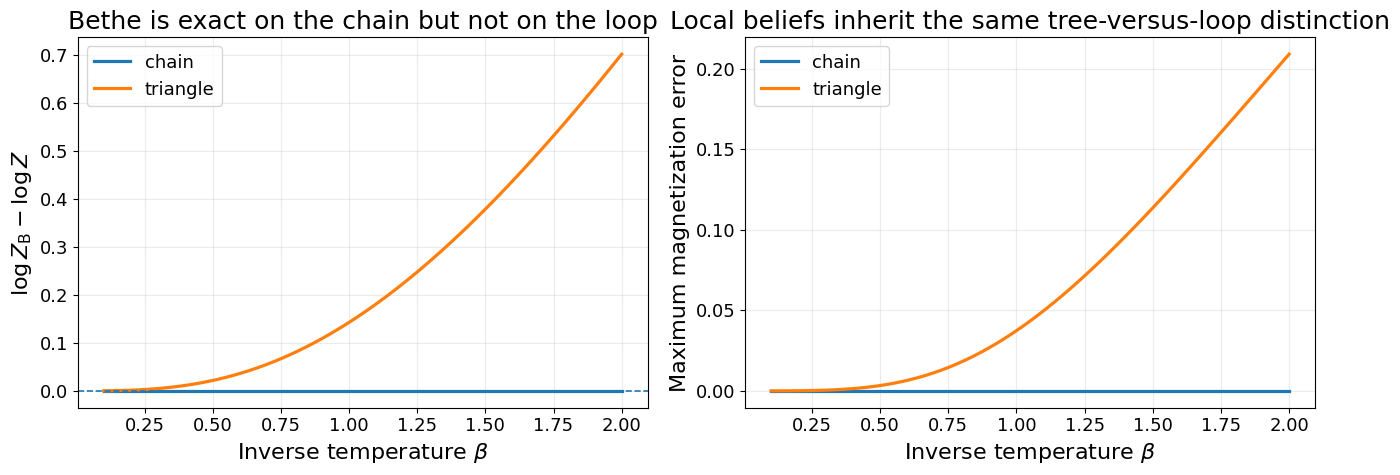

In [4]:
beta_grid = np.linspace(0.1, 2.0, 65)
results = {}
for name, model in models.items():
    exact_values = []
    bethe_values = []
    marginal_errors = []
    for beta in beta_grid:
        states, p, log_z = exact_pairwise(**model, beta=beta)
        node_b, edge_b, residual = loopy_bp(**model, beta=beta, damping=0.25)
        log_z_b, _ = bethe_log_z(**model, beta=beta, node_beliefs=node_b, edge_beliefs=edge_b)
        exact_m = p @ states
        bp_m = np.array([np.dot(b, SPINS) for b in node_b])
        exact_values.append(log_z)
        bethe_values.append(log_z_b)
        marginal_errors.append(np.max(np.abs(exact_m - bp_m)))
    results[name] = (np.asarray(exact_values), np.asarray(bethe_values), np.asarray(marginal_errors))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for name, (exact_values, bethe_values, _) in results.items():
    axes[0].plot(beta_grid, bethe_values - exact_values, linewidth=2.3, label=name)
axes[0].axhline(0, linewidth=1.2, linestyle="--")
axes[0].set_xlabel(r"Inverse temperature $\beta$")
axes[0].set_ylabel(r"$\log Z_{\mathrm{B}}-\log Z$")
axes[0].set_title("Bethe is exact on the chain but not on the loop")
axes[0].grid(alpha=0.25)
axes[0].legend()

for name, (_, _, marginal_errors) in results.items():
    axes[1].plot(beta_grid, marginal_errors, linewidth=2.3, label=name)
axes[1].set_xlabel(r"Inverse temperature $\beta$")
axes[1].set_ylabel("Maximum magnetization error")
axes[1].set_title("Local beliefs inherit the same tree-versus-loop distinction")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch06_02_bethe_accuracy")
plt.show()

assert np.max(np.abs(results["chain"][1] - results["chain"][0])) < 1e-8

## Entropy counting and mutual information

Saved: figs/ch06_02_entropy_counting.pdf


Saved: figs/ch06_02_entropy_counting.png


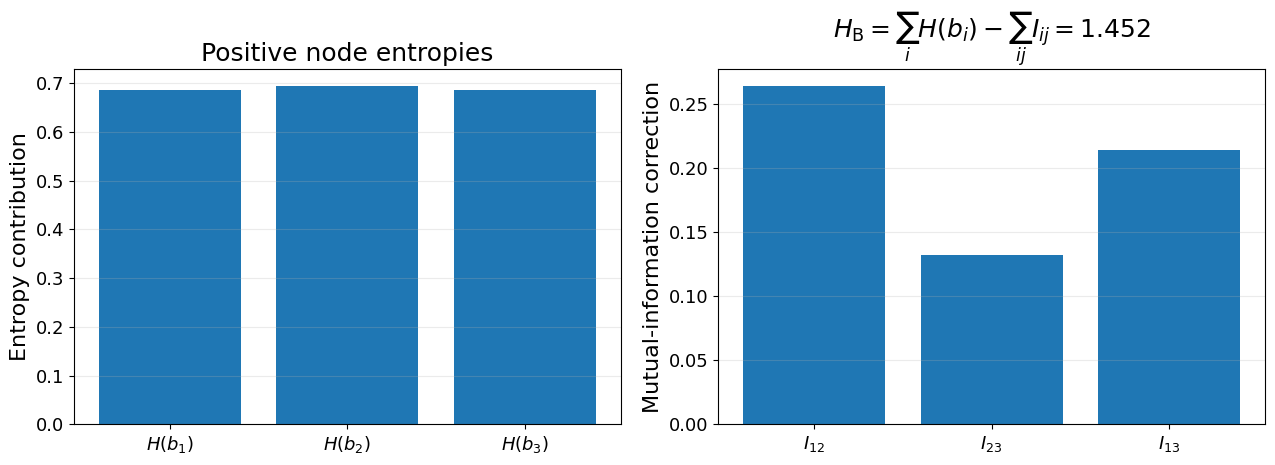

In [5]:
model = models["triangle"]
beta = 1.25
states, p, exact_log_z = exact_pairwise(**model, beta=beta)
node_b, edge_b, residual = loopy_bp(**model, beta=beta, damping=0.25)
bethe_value, h_bethe = bethe_log_z(**model, beta=beta, node_beliefs=node_b, edge_beliefs=edge_b)

node_entropies = np.array([entropy(b) for b in node_b])
mutual_information = []
for i, j in model["edges"]:
    joint = edge_b[(i, j)]
    product_belief = np.outer(node_b[i], node_b[j])
    mutual_information.append(np.sum(joint * np.log(np.clip(joint / product_belief, 1e-300, None))))
mutual_information = np.asarray(mutual_information)

assert np.isclose(h_bethe, node_entropies.sum() - mutual_information.sum(), atol=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.9))
axes[0].bar([rf"$H(b_{i+1})$" for i in range(model["n"])], node_entropies)
axes[0].set_ylabel("Entropy contribution")
axes[0].set_title("Positive node entropies")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar([rf"$I_{{{i+1}{j+1}}}$" for i, j in model["edges"]], mutual_information)
axes[1].set_ylabel("Mutual-information correction")
axes[1].set_title(rf"$H_{{\mathrm{{B}}}}=\sum_i H(b_i)-\sum_{{ij}}I_{{ij}}={h_bethe:.3f}$")
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch06_02_entropy_counting")
plt.show()

## Convergence and damping

Saved: figs/ch06_02_bp_convergence.pdf
Saved: figs/ch06_02_bp_convergence.png


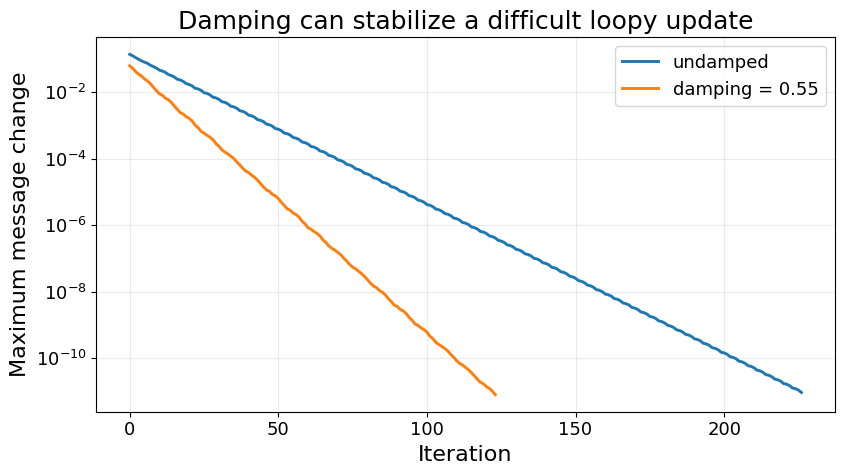

In [6]:
strong_model = {
    "n": 3,
    "edges": [(0, 1), (1, 2), (0, 2)],
    "couplings": {(0, 1): -1.15, (1, 2): -1.05, (0, 2): -1.10},
    "fields": np.array([0.22, -0.18, 0.08]),
}
beta = 1.4
_, _, residual_undamped = loopy_bp(**strong_model, beta=beta, damping=0.0, max_iterations=400)
_, _, residual_damped = loopy_bp(**strong_model, beta=beta, damping=0.55, max_iterations=400)

fig, ax = plt.subplots(figsize=(8.7, 5.0))
ax.semilogy(residual_undamped, linewidth=2.1, label="undamped")
ax.semilogy(residual_damped, linewidth=2.1, label="damping = 0.55")
ax.set_xlabel("Iteration")
ax.set_ylabel("Maximum message change")
ax.set_title("Damping can stabilize a difficult loopy update")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch06_02_bp_convergence")
plt.show()

## Exercises

1. **Basic.** Verify numerically that $H_{\mathrm B}$ equals the exact entropy on every tree in a randomly generated family of small trees.
2. **Extension.** Change one coupling in the triangle continuously from ferromagnetic to antiferromagnetic and locate the largest Bethe error.
3. **Algorithmic.** Compare parallel, sequential, and residual-based message scheduling.
4. **Research.** Numerically estimate the Jacobian of the BP update at a fixed point and compare its spectral radius with observed convergence.